In [4]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from flow_matching.solver import ODESolver
from torch.utils.data import TensorDataset, DataLoader
import time
import torch.nn as nn
from sklearn.decomposition import PCA
import seaborn as sns

import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')
from Data_Preparation import utils
import Modelisation.evaluation as ev
from utils import load_data_inlier, load_data_test, load_hyperparams

2026-04-08 09:46:15.619444: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
dataset_name = 'sms'
inlier_topic = 'normal'
type_tac = None
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

Dataset({
    features: ['text', 'label', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 3858
})
Dataset({
    features: ['text', 'label', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 966
})


In [8]:
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

model.eval()

@torch.no_grad()
def encode_tokens(texts, device, batch_size=16, max_length=128):
    all_embeddings = []
    all_tokens = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)
        last_hidden_state = outputs.last_hidden_state  # (B, T, D)

        # 🔥 normalisation token-wise (important pour distances locales)
        emb = torch.nn.functional.normalize(last_hidden_state, p=2, dim=2)

        all_embeddings.append(emb.cpu())

        # récupérer les tokens
        tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in inputs["input_ids"]]
        all_tokens.extend(tokens)

    return torch.cat(all_embeddings, dim=0).to(device), all_tokens

X_tokens_train, tokens_train = encode_tokens(data_train['text'], device)
X_tokens_test, tokens_test = encode_tokens(data_test['text'], device)
print(X_tokens_train.shape, X_tokens_test.shape)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([3858, 128, 768]) torch.Size([966, 128, 768])


In [11]:
import math
import torch
from torch import nn,  Tensor
import torch.nn.functional as F
from torch.optim import AdamW
import numpy as np
from flow_matching.solver import ODESolver
import time
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

def fpr95_score(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)  # 1 = anomalie
    idx = np.where(tpr >= 0.95)[0][0]
    return fpr[idx]

def evaluation(y_true, scores, verbose=True):

    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    fpr95 = fpr95_score(y_true, scores)

    if verbose:
        print(f"AUC:        {auc:.4f}")
        print(f"Avg Precision: {ap:.4f}")
        print(f"FPR@95:     {fpr95:.4f}")

    return auc, fpr95, ap

class BatchedVelocityWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, t):
        # t est scalaire → on l'étend au batch
        if t.dim() == 0:
            t = t.expand(x.shape[0])
        return self.model(x, t)

class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) *
            torch.arange(start=0, end=half, dtype=torch.float32) / half
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat(
                [embedding, torch.zeros_like(embedding[:, :1])], dim=-1
            )
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        return self.mlp(t_freq)


class DiTBlock(nn.Module):
    """
    Compatible sentence (B, D) et token (B, T, D)
    La clé : on ne squeeze/unsqueeze plus — on gère le shape en entrée
    """
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.attn  = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)

        mlp_hidden = int(hidden_size * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, mlp_hidden),
            nn.GELU(approximate="tanh"),
            nn.Linear(mlp_hidden, hidden_size)
        )
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True)
        )

        # Zero-init adaLN (comme l'original)
        nn.init.constant_(self.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.adaLN_modulation[-1].bias,   0)


    def forward(self, x, t, return_attention=False):
        """
        x : (B, D)    → sentence level
        x : (B, T, D) → token level
        c : (B, D)    → timestep embedding (toujours)
        """
        shift_msa, scale_msa, gate_msa, \
        shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN_modulation(t).chunk(6, dim=-1)  # (B, D) chacun

        # --- Gestion sentence vs token ---
        # is_sentence = (x.dim() == 2)
        # if is_sentence:
        #     x = x.unsqueeze(1)  # (B, 1, D) — séquence de longueur 1

        # Maintenant x est toujours (B, T, D)
        x_mod = modulate(self.norm1(x), shift_msa, scale_msa)  # (B, T, D)
        attn_out, attn_weights = self.attn(x_mod, x_mod, x_mod,
                              need_weights=True,
                              average_attn_weights=True)

        # gate : (B, D) → (B, 1, D) pour broadcaster sur T
        x = x + gate_msa.unsqueeze(1) * attn_out
        x = x + gate_mlp.unsqueeze(1) * self.mlp(
            modulate(self.norm2(x), shift_mlp, scale_mlp)
        )

        if return_attention:
            return x, attn_weights  # (B, T, T)

        return x, None


class FinalLayer(nn.Module):
    """Couche finale avec adaLN — comme l'original"""
    def __init__(self, hidden_size, out_dim):
        super().__init__()
        self.norm_final = nn.LayerNorm(
            hidden_size, elementwise_affine=False, eps=1e-6
        )
        self.linear = nn.Linear(hidden_size, out_dim, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size, bias=True)
        )
        # Zero-init
        nn.init.constant_(self.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.adaLN_modulation[-1].bias,   0)
        nn.init.constant_(self.linear.weight, 0)
        nn.init.constant_(self.linear.bias,   0)

    def forward(self, x, c):
        """
        x : (B, D) ou (B, T, D)
        c : (B, D)
        """
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=-1)
        x = modulate(self.norm_final(x), shift, scale)
        return self.linear(x)

def modulate(x, shift, scale):
    if x.dim() == 2:
        # Sentence level : (B, D)
        return x * (1 + scale) + shift
    else:
        # Token level : (B, T, D)
        return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class FlowDiT(nn.Module):
    """
    DiT générique : sentence level (B, D) ou token level (B, T, D)
    """
    def __init__(
        self,
        latent_dim=768,        # dimension par token SBERT
        hidden_dim=256,
        depth=4,
        n_heads=4,
        mlp_ratio=4.0,
        freq_embed_size=256,
    ):
        super().__init__()

        self.input_proj = nn.Linear(latent_dim, hidden_dim)

        # Timestep embedder
        self.t_embedder = TimestepEmbedder(hidden_dim, freq_embed_size)

        # Blocs DiT
        self.blocks = nn.ModuleList([
            DiTBlock(hidden_dim, n_heads, mlp_ratio)
            for _ in range(depth)
        ])

        # Couche finale avec adaLN
        self.final_layer = FinalLayer(hidden_dim, latent_dim)

        # Init weights
        self._init_weights()

    def _init_weights(self):
        def _basic_init(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        self.apply(_basic_init)

        # ✅ Ré-appliquer le zero-init APRÈS _basic_init
        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias,   0)

        # ✅ Zero-init FinalLayer APRÈS _basic_init
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias,   0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias,   0)

        # Timestep MLP
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)

    def forward(self, x_tokens, t, attention_mask=None, return_attention=False):
        """
        x_tokens       : (B, T, 768)  ← vrais token embeddings SBERT
        t              : (B,)
        attention_mask : (B, T)       ← 1=vrai token, 0=padding (optionnel)

        Retourne :
            v_sentence : (B, 768)     ← velocity field au niveau phrase
            v_tokens   : (B, T, 768)  ← velocity field par token
        """
        # Projection tokens → hidden_dim
        h = self.input_proj(x_tokens)       # (B, T, hidden_dim)

        # Timestep embedding
        c = self.t_embedder(t)              # (B, hidden_dim)

        # # DiT blocks
        # for block in self.blocks:
        #     h = block(h, c)                 # (B, T, hidden_dim)
        all_attentions = []
        for block in self.blocks:
            h, attn_w = block(h, c, return_attention=return_attention)
            if return_attention and attn_w is not None:
                all_attentions.append(attn_w)  # (B, T, T)


        # FinalLayer → velocity field par token
        v_tokens = self.final_layer(h, c)   # (B, T, 768)

        # ✅ Mean pooling avec masque si padding
        if attention_mask is not None:
            # Ne moyenne que sur les vrais tokens
            mask = attention_mask.unsqueeze(-1).float()  # (B, T, 1)
            v_sentence = (v_tokens * mask).sum(dim=1) / \
                          mask.sum(dim=1).clamp(min=1e-8) # (B, 768)
        else:
            v_sentence = v_tokens.mean(dim=1)            # (B, 768)

        if return_attention:
            # Stack : (n_blocks, B, T, T)
            all_attentions = torch.stack(all_attentions, dim=0)
            return v_sentence, v_tokens, all_attentions

        return v_sentence, v_tokens, None


class FlowMatchingTransformers(nn.Module):

    def __init__(self, model, source, target, config, noise_is_target, rectified):
        super().__init__()
        self.model = model
        self.source = source
        self.target = target
        self.noise_is_target = noise_is_target
        if self.noise_is_target:
            self.device = self.source.device
            # self.centroid = Tensor(self.source.mean(dim=0)).to(self.device)
            # self.var = Tensor(self.source.var(dim=0)).mean().to(self.device)
            # ✅ MODIF : centroid sur [CLS] uniquement (index 0)
            cls_tokens = self.source[:, 0, :]               # (N_samples, D)
            self.centroid = cls_tokens.mean(dim=0)          # (D,)
            self.var = cls_tokens.var(dim=0).mean()
            # self.centroid = torch.ones((self.source.shape[1]), device=self.device)*2
        else:
            self.device = self.target.device
            # ✅ MODIF : centroid sur [CLS] uniquement (index 0)
            cls_tokens = self.target[:, 0, :]               # (N_samples, D)
            self.centroid = cls_tokens.mean(dim=0)          # (D,)
            self.var = cls_tokens.var(dim=0).mean()
            # self.centroid = Tensor(self.target.mean(dim=0)).to(self.device)
            # self.var = Tensor(self.target.var(dim=0)).mean().to(self.device)
            # self.centroid = torch.ones((self.target.shape[1]), device=self.device)*2
        self.rectified = rectified
        self.config = config

        self.log_r = nn.Parameter(torch.tensor(0.0).to(self.device))

        # dist_train = torch.norm(self.source - self.centroid, dim=1)
        # r_init = torch.quantile(dist_train, 0.95)
        # self.log_r = nn.Parameter(torch.log(r_init))
        # print(self.log_r)


        # self.log_margin = nn.Parameter(torch.tensor(-1.0).to(self.device))
        self.log_margin = nn.Parameter(torch.tensor(0.0).to(self.device))
        # self.margin = 0.1


        # because the source and target distirbution are inlier and inlier_masked
        self.is_masking_task = type(self.config['source']) != str and type(self.config['target']) != str

    @property
    def margin(self):
        return torch.exp(self.log_margin) + 0.05

    @property
    def r_in(self):
        return torch.exp(self.log_r)

    @property
    def r_out(self):
        return self.r_in + self.margin

    def get_lr_schedule(self,epoch, warmup_epochs, total_epochs, lr):

        # return lr
        # linear increase
        if epoch < warmup_epochs:
            return lr * (epoch + 1) / (warmup_epochs + 1)
        # cosinus decrease
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return (lr * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)))).item()


    def get_lambda_kl(self, epoch, lambda_max, kl_warmup_epochs):
        return lambda_max * min(1.0, epoch / kl_warmup_epochs)

    def get_attention_maps(self, x_tokens, t_val=0.5, attention_mask=None):
        """
        Retourne les attention maps de tous les blocs
        x_tokens : (B, T, 768)
        → all_attentions : (n_blocks, B, T, T)
        """
        self.model.eval()
        with torch.no_grad():
            t = torch.full((x_tokens.shape[0],), t_val, device=self.device)

            _, _, all_attentions = self.model(
                x_tokens, t,
                attention_mask=attention_mask,
                return_attention=True
            )

        return all_attentions  # (n_blocks, B, T, T)

    def sample_like(self, x_0, type, tail=None):

        if type == 'gaussian':
            return torch.randn_like(x_0)

        if type == 'gaussian-neigh':
            B, T, D = x_0.shape
            sigma = torch.sqrt(self.var * self.config['coef_var'])
            # x_mean = x_0.mean(dim=1, keepdim=True).expand_as(x_0)  # (B, T, 768)
            # return x_mean + sigma * torch.randn_like(x_0)
            if self.centroid.dim == 1:
                self.centroid = self.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1)
            return self.centroid + sigma * torch.randn_like(x_0)

        if type == 'centroid':
            return self.centroid.repeat(x_0.shape[0],1)

        if type =='sphere-noised':
            z = torch.randn(x_0.shape[0], x_0.shape[1])
            z = z / z.norm(dim=1, keepdim=True)
            noise = torch.randn_like(z) * 0.25
            return Tensor(z + noise).to(self.device)

        if type == 'sphere':
            z = torch.randn(x_0.shape[0], x_0.shape[1])
            return Tensor(z / z.norm(dim=1, keepdim=True)).to(self.device)


    def euler_integrate(self, x_0, N_steps=10):
        with torch.no_grad():
          x_t = x_0
          dt = 1.0 / N_steps

          velocities_tokens = []

          for i in range(N_steps):
              t_val = i * dt
              t = torch.full((x_t.shape[0],), t_val, device=self.device)
              v_sen, v_tokens, _ = self.model(x_t, t)
              x_t = x_t + dt * v_tokens
              velocities_tokens.append(v_tokens.detach())

          velocities_tokens = torch.stack(velocities_tokens)

          return x_t, velocities_tokens


    def compute_flow_loss(self, x_0, indices, flow_type='linear', sigma=0.1, warmup_activated=False):


        ##########################################
        ############ NEGATIVE SAMPLING ###########
        ##########################################

        if not warmup_activated:

            x_sentence = x_0[:, 0, :]
            # x_sentence = x_0.mean(dim=1)

            # garde fou
            nb_samples_neg = int((self.config['rate_neg_batch'] * x_sentence.shape[0]) / 3)
            if nb_samples_neg < 1:
                nb_samples_neg = 5

            x_0_negative = []
            sigma_levels = torch.tensor(self.config['sig_levels_neg']).to(self.device) * torch.sqrt(self.var)
            for i,sig in enumerate(sigma_levels):

                eps = sig * torch.randn((i+1)*nb_samples_neg, x_sentence.shape[1]).to(self.device)
                x_0_negative.extend(self.centroid + eps)
            x_0_negative = torch.stack(x_0_negative).to(self.device)

            # direction = torch.randn_like(x_0)
            # direction = direction / direction.norm(dim=1, keepdim=True)
            # alpha = 1.1
            # x_0_negative = x_0 + alpha * direction


            # p = 0.10
            # sigma = 0.75
            # mask = torch.rand_like(x_0) < p  # p = proportion de dims perturbées
            # noise = torch.randn_like(x_0) * sigma
            # x_0_negative = x_0 + mask * noise


            # direction = x_0 - self.centroid                                        # (B, D)
            # direction_norm = torch.norm(direction, dim=1, keepdim=True) + 1e-8    # (B, 1)
            # direction_normalized = direction / direction_norm                       # (B, D)

            # with torch.no_grad():
            #     r_in_val  = self.r_in.item()
            #     r_out_val = self.r_out.item()

            #     # Sample distance aléatoire strictement dans [r_in, r_out]
            #     # → push loss TOUJOURS active
            #     alpha = torch.rand(x_0.shape[0], 1, device=self.device)
            #     target_dist = r_in_val + alpha * (r_out_val - r_in_val)           # (B, 1)

            # x_0_negative = self.centroid + target_dist * direction_normalized             # (B, D)

            # sigma_levels = [
            #     # 0.9 * torch.sqrt(self.var),
            #     # 1.3 * torch.sqrt(self.var)

            #     0.5 * torch.sqrt(self.var),
            #     0.7 * torch.sqrt(self.var)
            #     # 0.7 * torch.sqrt(self.var),
            #     # 0.9 * torch.sqrt(self.var)

            #     # 0.3 * torch.sqrt(self.var),
            #     # 0.5 * torch.sqrt(self.var)
            # ]

            # alpha = 1.2
            # direction = x_0 - self.centroid
            # all_x_0_negative = self.centroid + alpha * direction
            # x_0_negative = all_x_0_negative[torch.randint(0,x_0.shape[0],(nb_samples_neg,))]


        ##########################################
        ##########################################

        if self.target == 'gaussian' or self.source == 'gaussian':
            x_1 = self.sample_like(x_0, 'gaussian')

        if self.target == 'gaussian-neigh' or self.source == 'gaussian-neigh':
            x_1 = self.sample_like(x_0, 'gaussian-neigh')

        if self.target == 'centroid' or self.source == 'centroid':
            x_1 = self.sample_like(x_0, 'centroid')

        if self.target == 'sphere' or self.source == 'sphere':
            x_1 = self.sample_like(x_0, 'sphere-noised')

        if self.target == 'sphere-noised' or self.source == 'sphere-noised':
            x_1 = self.sample_like(x_0, 'sphere-noised')

        batch_size = x_1.shape[0]
        t = torch.rand(batch_size, device=self.device)

        # j'inverse juste la source et la target
        if not self.noise_is_target:
            x_0, x_1 = x_1, x_0

        if flow_type == 'linear':

            t_expanded = t.view(-1, 1, 1)
            x_t = t_expanded * x_1 + (1 - t_expanded) * x_0
            v_target = x_1 - x_0

        elif flow_type == 'cfm':
            t_expanded = t.view(-1, 1, 1)
            mu_t = t_expanded * x_1 + (1 - t_expanded) * x_0

            eps = torch.randn_like(x_0)
            x_t = mu_t + sigma * eps

            v_target = x_1 - x_0

        else:
            raise ValueError(f"Unknown flow_type: {flow_type}")

        # v_pred = self.model(x_t, t)
        v_pred, v_tokens, _ = self.model(x_t, t)

        # <<<<<<<<<<<<<<<<<<<<< LOSS FM >>>>>>>>>>>>>>>>>>>>>>>>>>>>
        # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
        loss_fm = F.mse_loss(v_tokens, v_target)

        # loss_fm = torch.tensor(0.0, device=self.device, requires_grad=True)

        loss_svdd = torch.tensor(0.0, device=self.device)
        loss_push = torch.tensor(0.0, device=self.device)

        if not warmup_activated:

            # <<<<<<<<<<<<<<<<<<<<< LOSS SVDD >>>>>>>>>>>>>>>>>>>>>>>>>>>>
            # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
            if self.config['lambda_svdd'] > 0:
                x_svdd, _ = self.euler_integrate(x_0, N_steps=self.config['n_step_euler_integrate'])

                x_mean = x_0.mean(dim=1, keepdim=True).expand_as(x_0)  # (B, T, 768)
                # dist_sq = torch.sum((x_svdd - self.centroid)**2, dim=1)
                dist_sq = torch.sum((x_svdd - x_mean)**2, dim=1)

                r_sq = self.r_in ** 2
                loss_svdd = r_sq + F.relu(dist_sq - r_sq).mean()

            # <<<<<<<<<<<<<<<<<<<<< LOSS PUSH >>>>>>>>>>>>>>>>>>>>>>>>>>>>
            # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
            if self.config['lambda_push'] > 0:

                # ---------------- PUSH RELU ---------------

                x_neg, _  = self.euler_integrate(x_0_negative, N_steps=self.config['n_step_euler_integrate'])

                dist_out = torch.norm(x_neg - self.centroid, dim=1)

                loss_push = F.relu(self.r_out - dist_out).mean()

                # ---------------- PUSH VELOCITY DIRECTION  ---------------

                # t = torch.rand(x_0_negative.shape[0], device=self.device)
                # v = self.model(x_0_negative, t)
                # v_normalized = v / (torch.norm(v, dim=1, keepdim=True) + 1e-8)
                # direction_out = x_0_negative - self.centroid
                # direction_out = direction_out / (
                # torch.norm(direction_out, dim=1, keepdim=True) + 1e-8
                # )
                # radial_component = (v_normalized * direction_out).sum(dim=1)
                # loss_push = -radial_component.mean()


                # ---------------- PUSH COSINUS SIM  ---------------

                # v_neg  = self.model(x_0_negative,  t)
                # cos_sim = F.cosine_similarity(v_pred, v_neg, dim=1)

                # loss_push = cos_sim.mean()


            # <<<<<<<<<<<<<<<<<<<<< REGUL MARGIN >>>>>>>>>>>>>>>>>>>>>>>>>>>>
            # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

            loss_total = loss_fm + self.config['lambda_svdd'] * loss_svdd \
                  + self.config['lambda_push'] * loss_push + self.config['lambda_margin'] * self.margin

            # print(f"Loss FM : {loss_fm}")
            # print(f"Loss SVDD : {loss_svdd}")
            # print(f"Loss Push : {loss_push}")
            # print(f"Loss Tot : {loss_total}")
            # print("----------------------------------------")

            return loss_total, loss_fm.item(), loss_svdd.item(), loss_push.item(), self.margin.item(), self.r_in.item()

        else:

            loss_total = loss_fm
            return loss_total, 0, 0, 0, 0, 0


    def train_epoch(self, dataloader, optimizer, warmup_activated):

        self.model.train()
        self.optimizer = optimizer

        total_loss_liste = []
        loss_fm_liste = []
        loss_svdd_liste = []
        loss_push_liste = []
        margin_value_liste = []
        r_in_value_liste = []

        # for x_0, y, indices in dataloader:
        for x_0, indices in dataloader:

            x_0 = x_0.to(self.device)
            loss_total, *anythingelse = self.compute_flow_loss(
            # loss_total, loss_fm, loss_svdd, loss_push, margin_value, r_in_value = self.compute_flow_loss(
                x_0,
                indices,
                flow_type=self.config['flow_type'],
                sigma=self.config['sigma'],
                warmup_activated=warmup_activated
            )

            self.optimizer.zero_grad()
            loss_total.backward()

            torch.nn.utils.clip_grad_norm_(
                list(self.model.parameters()) + [self.log_r, self.log_margin],
                self.config['grad_clip']
            )

            self.optimizer.step()

            total_loss_liste.append(loss_total.item())
            loss_fm_liste.append(anythingelse[0])
            loss_svdd_liste.append(anythingelse[1])
            loss_push_liste.append(anythingelse[2])
            margin_value_liste.append(anythingelse[3])
            r_in_value_liste.append(anythingelse[4])

        return np.mean(total_loss_liste), np.mean(loss_fm_liste), np.mean(loss_svdd_liste),\
              np.mean(loss_push_liste),  np.mean(margin_value_liste), np.mean(r_in_value_liste)


    def train(self, verbose=True):

        optimizer = AdamW(
            # self.model.parameters(),
            list(self.model.parameters()) + [self.log_r] + [self.log_margin],
            lr=self.config['lr'],
            weight_decay=self.config['weight_decay'],
            foreach=False
        )

        if self.noise_is_target:
            X_inlier = self.source
        else:
            X_inlier = self.target

        # X_inlier_dl = DataLoader(TensorDataset(X_inlier, self.config['y_train'], torch.arange(len(X_inlier))), batch_size=self.config['batch_size'], shuffle=True)
        X_inlier_dl = DataLoader(TensorDataset(X_inlier, torch.arange(len(X_inlier))), batch_size=self.config['batch_size'], shuffle=True)


        total_loss_liste = []
        loss_fm_liste = []
        loss_svdd_liste = []
        loss_push_liste = []
        margin_value_liste = []
        r_in_value_liste = []


        for epoch in range(self.config['epochs']):
            warmup_activated = epoch <= self.config['warmup_epochs']

            if self.config['warmup_epochs'] == 0 and epoch == self.config['warmup_epochs']:
                self.log_r.data.fill_(0.0)
                print(f"Initialization r_in : {self.r_in}")

            elif epoch == self.config['warmup_epochs']:
                self.model.eval()
                with torch.no_grad():
                    # t_zeros = torch.zeros(X_inlier.shape[0]).to(self.device)
                    # v = self.model(X_inlier, t_zeros)
                    # phi_1 = X_inlier + v

                    # dist_train = torch.norm(phi_1 - self.centroid, dim=1)
                    # r_init = torch.quantile(dist_train, 0.90)
                    # self.log_r.data.fill_(torch.log(r_init).item())
                    all_dists = []
                    for x_batch, _ in X_inlier_dl:
                        x_batch = x_batch.to(self.device)
                        t_zeros = torch.zeros(x_batch.shape[0]).to(self.device)
                        v = self.model(x_batch, t_zeros)
                        phi_1 = x_batch + v
                        dist = torch.norm(phi_1 - self.centroid, dim=1)
                        all_dists.append(dist)

                    all_dists = torch.cat(all_dists)
                    r_init = torch.quantile(all_dists, 0.90)
                    self.log_r.data.fill_(torch.log(r_init).item())
                print(f"FM Warmup is finished after .... initialization r_in : {self.r_in}")
                self.model.train()

            lr = self.get_lr_schedule(epoch, self.config['lr_epochs'], self.config['epochs'], self.config['lr'])
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            loss_total, *anythingelse = self.train_epoch(
            # loss_total, loss_fm, loss_svdd, loss_push, margin_value, r_in_value = self.train_epoch(
                X_inlier_dl,
                optimizer,
                warmup_activated,
            )

            # with torch.no_grad():
                # print(f"Epoch {epoch} - Push loss : {anythingelse[2]}")
                # print(f"Epoch {epoch} - FM loss : {anythingelse[0]}")
                # print(f"Epoch {epoch} - SVDD loss : {anythingelse[1]}")
            #     print(lr)
            #     print("----------------------------------")
            total_loss_liste.append(loss_total.item())
            loss_fm_liste.append(anythingelse[0])
            loss_svdd_liste.append(anythingelse[1])
            loss_push_liste.append(anythingelse[2])
            margin_value_liste.append(anythingelse[3])
            r_in_value_liste.append(anythingelse[4])

            if epoch % (self.config['epochs'] // 3) == 0 and verbose:
                print(f"\nEpoch {epoch+1}/{self.config['epochs']}")
                print(f"Train Loss: {loss_total:.4f}, LR: {lr:.6f}")

        if self.rectified is None:
            return total_loss_liste, loss_fm_liste, loss_svdd_liste, \
                    loss_push_liste, margin_value_liste, r_in_value_liste

        else:
            print(f"\nRectification Pass starting.... for {self.rectified} iterations")

            for iteration in range(self.rectified):
                l = []
                for x_0, in X_inlier_dl:

                    traj, v_rectified = self.generate_rectified_targets(self.model, x_0)
                    loss = self.rectified_flow_iterative_loss(self.model, traj, v_rectified)

                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                    l.append(loss.item())

                print(f"Rectification iteration {iteration+1}, loss = {np.mean(l):.6f}")

            return liste_loss

    @torch.no_grad()
    def generate_rectified_targets(self, model, x0, steps=50):
        B = x0.shape[0]
        x = x0.clone()
        dt = 1.0 / steps

        traj = []
        for i in range(steps):
            t = torch.full((B,), i * dt, device=x.device)
            x = x + model(x, t) * dt
            traj.append(x.clone())

        xT = x
        v_rectified = (xT - x0)

        return traj, v_rectified

    def rectified_flow_iterative_loss(self, model, traj, v_rectified):
        losses = []
        steps = len(traj)

        for i, xt in enumerate(traj):
            B = xt.shape[0]
            t = torch.full((B,), i / steps, device=xt.device)
            v_pred = model(xt, t)
            losses.append(((v_pred - v_rectified) ** 2).mean())

        return sum(losses) / len(losses)

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):

        self.model.eval()
        wrapped_model = BatchedVelocityWrapper(self.model)
        solver = ODESolver(velocity_model=wrapped_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        # x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=False)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):

        self.model.eval()
        wrapped_model = BatchedVelocityWrapper(self.model)
        solver = ODESolver(velocity_model=wrapped_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        # x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=False)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source

    @torch.no_grad()
    def compute_anomaly_scores(self, X_test, X_inlier,
                            type='mahalanobis',
                            n_steps=20,
                            solver_type="midpoint"):

        ##################################
        ########### TEST DATA ############
        ##################################

        if self.noise_is_target:
            # forward ODE : test -> noise
            out = self.forward_flow(X_test.to(self.device), solver_type=solver_type, n_steps=n_steps)
        else:
            # backward ODE : noise -> test
            out = self.backward_flow(X_test.to(self.device), solver_type=solver_type, n_steps=n_steps)

        x_1_test = out[-1].cpu().numpy()

        ##########################################
        ########### INLIERS (TRAIN) ##############
        ##########################################

        if type == 'mahalanobis':

            if self.noise_is_target:
                # forward ODE : inlier -> noise
                out_in = self.forward_flow(X_inlier.to(self.device), solver_type=solver_type, n_steps=n_steps)
            else:
                # backward ODE : noise -> inlier
                out_in = self.backward_flow(X_inlier.to(self.device), solver_type=solver_type, n_steps=n_steps)

            x_1_inliers = out_in[-1].cpu().numpy()

            mean_inlier = np.mean(x_1_inliers, axis=0)
            cov_inlier = np.cov(x_1_inliers.T)
            cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

            diff = x_1_test - mean_inlier
            inv_cov = np.linalg.inv(cov_inlier)

            scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

        ##################################
        ########### NORMS ################
        ##################################
        elif type == 'norm':
            scores = np.sum(x_1_test ** 2, axis=1)

        elif type == 'norm-centroid':
            # scores = np.sum((x_1_test[:, 0, :] - self.centroid.repeat(x_1_test.shape[0],1).cpu().numpy()) ** 2, axis=1)
            scores = np.sum((x_1_test - self.centroid.repeat(x_1_test.shape[0],1).cpu().numpy()) ** 2, axis=1)

        ##################################
        ######## RECONSTRUCTION ##########
        ##################################
        elif type == 'recons':

            if self.noise_is_target:
                out_back = self.backward_flow(torch.tensor(x_1_test, device=self.device), solver_type=solver_type, n_steps=n_steps)
            else:
                out_back = self.forward_flow(torch.tensor(x_1_test, device=self.device), solver_type=solver_type, n_steps=n_steps)

            x_0_back = out_back[-1]
            scores = (
                torch.norm(x_0_back - X_test, dim=1) ** 2
            ).cpu().numpy()

        return scores

    def test(self, X_test, y_test, X_inlier, type='norm-centroid'):

        scores = self.compute_anomaly_scores(X_test, X_inlier, type)
        return evaluation(y_test, scores, verbose=False)

In [12]:
nb_random_samples = 1000

config = {
        'latent_dim': 768,
        'hidden_dim': 256,
        'depth': 4,
        'n_heads': 4,
        'mlp_ratio': 4.0,
        'n_patches': 1,
        'freq_embed_size': 128,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'lambda_svdd': 1e-3,
        'lambda_push': 0,
        'lambda_margin': 0,
        'epochs': 500,
        'lr_epochs': 150,
        'warmup_epochs': -1,
        'grad_clip': 0.5,
        'flow_type': 'linear',
        'sigma': 0.1,
        'batch_size' : 256,
        'lambda_reg_angle': None,
        'lambda_reg_kl': None,
        'n_step_euler_integrate' : 1,
        'coef_var': 1,
        'rate_neg_batch':1.0,
        'sig_levels_neg' : [0.5, 0.7],
        'target' : 'gaussian-neigh',
        # 'source' : X_inlier.to(device)
        'source' : X_tokens_train.to(device)
        
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert',
    'source' : config['source'] if not noise_is_target else 'SBert'
}

flowmodel = FlowDiT(
            latent_dim=config['latent_dim'],
            hidden_dim=config['hidden_dim'],
            depth=config['depth'],
            n_heads=config['n_heads']
    ).to(device)

fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)

In [ ]:
total_loss_liste, loss_fm_liste, loss_svdd_liste, loss_push_liste, margin_value_liste, r_in_value_liste = \
    fm_transformer.train(True)


Epoch 1/500
Train Loss: 0.0014, LR: 0.000001

Epoch 167/500
Train Loss: 0.0008, LR: 0.000099

Epoch 333/500
Train Loss: 0.0006, LR: 0.000047


In [ ]:
x_after, velocities_tokens = fm_transformer.euler_integrate(X_tokens_test.to(device), 15)
x_after.shape

In [10]:
# x_after, velocities_tokens = fm_transformer.euler_integrate(X_test[:500].to(device), 15)
# B, T, D = x_after.shape
# scores = np.sum((x_after.cpu().numpy() - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1).cpu().numpy()) ** 2, axis=2)
# evaluation(y_test[:B], scores.mean(axis=1))
# # fm_transformer.test(X_test[:10], y_test[:10], X_inlier, 'norm-centroid')

In [11]:
name = f"centroid_20ng_attn_max_len_256_dim_{config['hidden_dim']}_ep{config['epochs']}"
saving_path = f'/content/drive/MyDrive/Flow Matching/models/{name}'
checkpoint = {
    "model": fm_transformer.model.state_dict(),
    "config": config
}
torch.save(checkpoint, saving_path)

In [9]:
name = f"centroid_20ng_attn_max_len_256_dim_{config['hidden_dim']}_ep{config['epochs']}"
model_saving_path = f'/content/drive/MyDrive/Flow Matching/models/{name}'

checkpoint = torch.load(model_saving_path, map_location=device)
config = checkpoint["config"]

flowmodel = FlowDiT(
    latent_dim=config['latent_dim'],
    hidden_dim=config['hidden_dim'],
    depth=config['depth'],
    n_heads=config['n_heads']
).to(device)

flowmodel.load_state_dict(checkpoint["model"])
flowmodel.eval()

fm_transformer = FlowMatchingTransformers(
    flowmodel,
    config['source'],
    config['target'],
    config,
    noise_is_target=True,
    rectified=None
)

In [11]:
print(test_texts[0])
tokens = tokenizer.tokenize(test_texts[0])
print(len(tokens))
print(tokens)

It's the video card. It's 8514/A compatible, which means it uses the same i/o addresses as com4. --jh
31
['It', "'s", 'Ġthe', 'Ġvideo', 'Ġcard', '.', 'ĠIt', "'s", 'Ġ85', '14', '/', 'A', 'Ġcompatible', ',', 'Ġwhich', 'Ġmeans', 'Ġit', 'Ġuses', 'Ġthe', 'Ġsame', 'Ġi', '/', 'o', 'Ġaddresses', 'Ġas', 'Ġcom', '4', '.', 'Ġ--', 'j', 'h']


In [16]:
data = X_test[y_test==0][:10].to(device)
# data = X_inlier[:10].to(device)
x_after, velocities_tokens = fm_transformer.euler_integrate(data, 15)

/tmp/ipykernel_17335/1543173488.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', G)


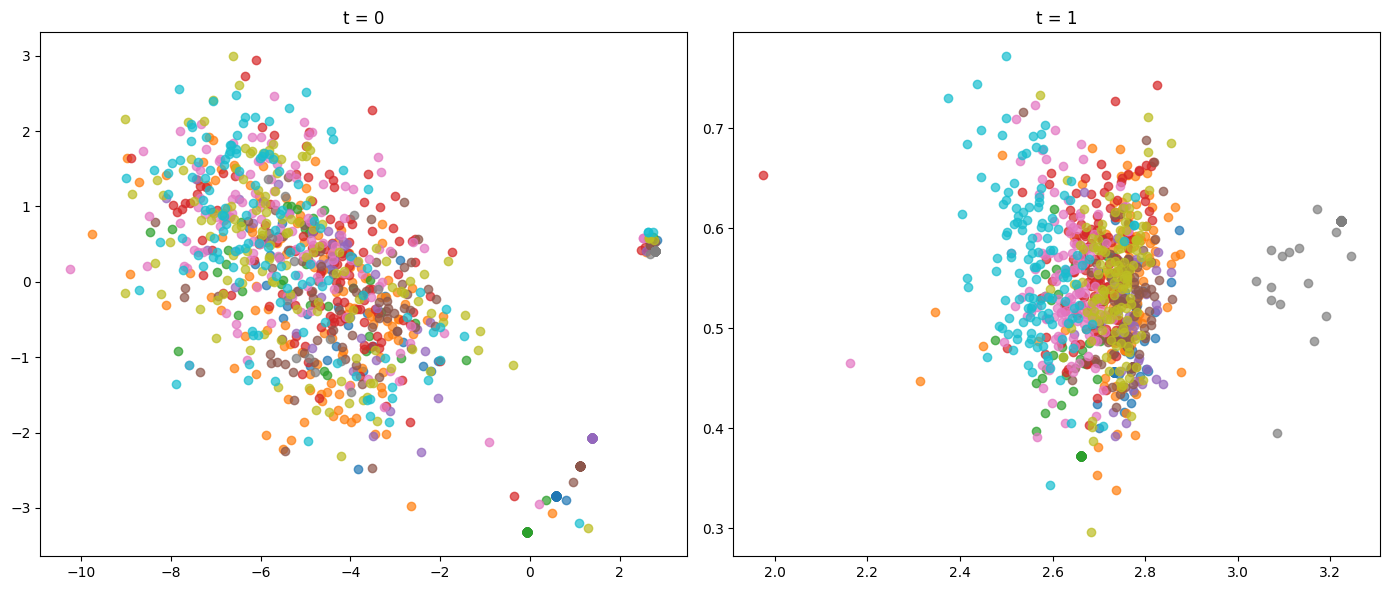

In [17]:
G, N, D = x_after.shape

x_all = torch.cat([
    x_after.view(-1, D),
    data.view(-1, D)
], dim=0).detach()

pca = PCA(n_components=2)
pca.fit(x_all.cpu().numpy())

def project(x):
    G, N, D = x.shape
    x_flat = x.view(-1, D).detach()
    x_pca = pca.transform(x_flat.cpu().numpy())
    return x_pca.reshape(G, N, 2)

x_after_pca = project(x_after)
x_inlier_pca = project(data)

cmap = plt.cm.get_cmap('tab10', G)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for i in range(G):
    axes[0].scatter(
        x_inlier_pca[i, :, 0],
        x_inlier_pca[i, :, 1],
        color=cmap(i),
        alpha=0.7
    )

axes[0].set_title("t = 0")
# axes[0].grid()

for i in range(G):
    axes[1].scatter(
        x_after_pca[i, :, 0],
        x_after_pca[i, :, 1],
        color=cmap(i),
        alpha=0.7
    )

axes[1].set_title("t = 1")
# axes[1].grid()

plt.tight_layout()
plt.show()

/tmp/ipykernel_11755/3373869468.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(selected_idx))


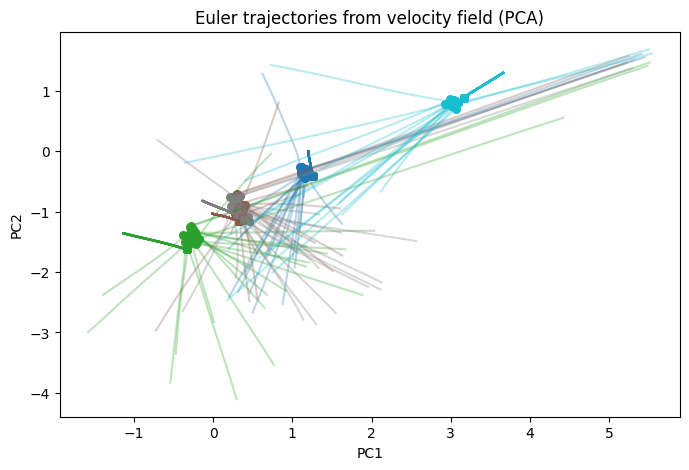

In [ ]:
velocities = velocities_tokens
T, G, N, D = velocities.shape

# condition initiale (t=0)
x0 = data.clone()  # (G, N, D)

# ===== PARAM =====
dt = 1.0 / T  # ou 1.0 si déjà discretisé comme ça
max_sentences = 5

selected_idx = np.random.choice(G, size=min(max_sentences, G), replace=False)

# ===== 1. Euler integration =====
x_traj = [x0]

x_t = x0.clone()
dt = 1.0 / T
for t in range(T):
    v_t = velocities[t]
    x_t = x_t + dt * v_t
    x_traj.append(x_t)

# (T+1, G, N, D)
x_traj = torch.stack(x_traj)

# ===== 2. PCA =====
x_flat = x_traj.reshape(-1, D).detach()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_flat.cpu().numpy())

x_pca = x_pca.reshape(T+1, G, N, 2)

# ===== 3. Plot =====
plt.figure(figsize=(8,5))
cmap = plt.cm.get_cmap('tab10', len(selected_idx))

for i, g in enumerate(selected_idx):
    color = cmap(i)

    for n in range(N):
        traj = x_pca[:, g, n, :]  # (T+1, 2)

        # trajectoire
        plt.plot(
            traj[:, 0],
            traj[:, 1],
            color=color,
            alpha=0.3
        )

        # point initial
        # plt.scatter(
        #     traj[0, 0],
        #     traj[0, 1],
        #     color=color,
        #     marker='x',
        #     alpha=0.8
        # )

        # point final
        plt.scatter(
            traj[-1, 0],
            traj[-1, 1],
            color=color,
            s=30
        )

plt.title("Euler trajectories from velocity field (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.grid()
plt.show()

In [18]:
x_after_anom, velocities_tokens_anom = fm_transformer.euler_integrate(X_test[y_test==1].to(device), 15)
x_after_inli, velocities_tokens_inli = fm_transformer.euler_integrate(X_test[y_test==0].to(device), 15)

OutOfMemoryError: CUDA out of memory. Tried to allocate 478.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 183.81 MiB is free. Including non-PyTorch memory, this process has 14.38 GiB memory in use. Of the allocated memory 12.39 GiB is allocated by PyTorch, and 1.85 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [17]:
B, T, D = torch.concatenate([x_after_inli, x_after_anom]).shape
scores = np.sum((torch.concatenate([x_after_inli, x_after_anom]).cpu().numpy() - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1).cpu().numpy()) ** 2, axis=2)
evaluation(torch.tensor([0]*x_after_inli.shape[0] + [1]*x_after_anom.shape[0]), scores.mean(axis=1))

AUC:        0.7843
Avg Precision: 0.4013
FPR@95:     0.9048


(np.float64(0.7842937416609818),
 np.float64(0.9047619047619048),
 np.float64(0.40134479045969074))

In [29]:
np.sort(scores[-1])

array([ 0.41028428,  0.5762651 ,  0.57626575,  1.3494508 ,  1.3494508 ,
        1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,
        1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,
        1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,
        1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,  1.3494508 ,
        1.3494508 ,  2.5542774 ,  3.5551174 ,  4.1228156 ,  4.4073334 ,
        4.5538235 ,  5.0752463 ,  5.122393  ,  5.177263  ,  5.3501463 ,
        5.3963714 ,  5.7848153 ,  5.8072257 ,  5.85994   ,  5.915762  ,
        6.140371  ,  6.3457603 ,  6.5467167 ,  6.6315947 ,  6.7429786 ,
        6.7961903 ,  7.133343  ,  7.3441334 ,  8.015141  ,  8.068516  ,
        8.139594  ,  8.182234  ,  8.35816   ,  8.66177   ,  8.827148  ,
        9.082244  ,  9.295071  ,  9.492399  , 10.766465  , 10.833612  ,
       11.390694  , 13.002861  , 14.730782  , 15.502739  ], dtype=float32)

In [ ]:
x_after, velocities_tokens = fm_transformer.euler_integrate(X_test.to(device), 15)
B, T, D = x_after.shape
scores = np.sum((x_after.cpu().numpy() - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1).cpu().numpy()) ** 2, axis=2)
evaluation(y_test, scores.mean(axis=1))

OutOfMemoryError: CUDA out of memory. Tried to allocate 396.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 181.81 MiB is free. Including non-PyTorch memory, this process has 14.38 GiB memory in use. Of the allocated memory 12.68 GiB is allocated by PyTorch, and 1.57 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
def compactness_variance(X):
  ll = []
  for x in X:
    mu = x.mean(dim=0, keepdim=True)
    ll.append(((x - mu)**2).sum(dim=1).mean().item())
  return np.array(ll)

def compactness_pairwise(X):
    ll = []
    for x in X:
      dist = torch.cdist(x, x)
      ll.append(dist.mean().item())
    return np.array(ll)

print(compactness_variance(x_after_inli).mean())
print(compactness_variance(x_after_anom).mean())
_, _, _ = evaluation(y_test, compactness_variance(X_test))
print("-------------------------------------")

print(compactness_pairwise(x_after_inli).mean())
print(compactness_pairwise(x_after_anom).mean())
_, _, _ = evaluation(y_test, compactness_pairwise(X_test))
print("-------------------------------------")

4.817849198548286
6.155746867207332
AUC:        0.4137
Avg Precision: 0.0742
FPR@95:     0.9477
-------------------------------------
2.913688228563574
3.289872189622899
AUC:        0.4234
Avg Precision: 0.0759
FPR@95:     0.9388
-------------------------------------


In [ ]:
import re

def get_tokens(tokenizer, data):
    return [
        # [re.sub(r"[ĠĊ]", "", t) for t in tokenizer.tokenize(dt['sms'])]
        [re.sub(r"[ĠĊ]", "", t) for t in tokenizer.tokenize(dt['text'])]
        for dt in data
    ]

def plot_heatmap(importance, tokens, idx):
    scores = importance[idx].detach().cpu().numpy().reshape(1, -1)
    toks = tokens[idx]

    plt.figure(figsize=(max(10, len(toks) * 0.5), 2))

    ax = sns.heatmap(
        scores,
        cmap="Reds",
        cbar=True,
        xticklabels=toks,
        yticklabels=[]
    )

    # rotation pour lisibilité
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Token importance - sample {idx}")

    plt.tight_layout()
    plt.show()

In [ ]:
token_importance_anom = torch.norm(velocities_tokens_anom[-1], dim=-1)
token_importance_anom = token_importance_anom / token_importance_anom.sum(dim=1, keepdim=True)
# test_data_anom = test_data.filter(lambda x: x['label'] == 1)
test_data_anom = test_outliers_sampled
tokens_anom = get_tokens(tokenizer, test_data_anom)

# plot_heatmap(token_importance_anom, tokens_anom, idx=0)

NameError: name 'velocities_tokens_anom' is not defined

In [ ]:
print(token_importance_anom.argmax(dim=1).shape)
print(tokens_anom[0])

torch.Size([191])
['What', 'is', 'your', 'proof', 'that', 'they', '"', 'did', 'the', 'best', 'they', 'could', '"?', 'Unless', 'they', 'had', 'strong', 'evidence', 'that', 'the', 'children', 'were', 'in', 'IM', 'MED', 'I', 'ATE', 'danger', 'then', '"', 'the', 'best', 'they', 'could', '"', 'have', 'done', 'was', 'to', 'SHOW', 'REST', 'RA', 'INT', '.', 'Some', 'of', 'us', 'DID', 'predict', 'this', 'outcome', ',', 'or', 'at', 'least', 'suggested', 'a', 'strong', 'possibility', 'of', 'it', '.', 'I', ',', 'for', 'one', ',', 'said', 'that', 'in', 'the', 'event', 'of', 'an', 'assault', 'against', 'the', 'building', 'the', 'CH', 'IL', 'DR', 'EN', 'were', 'the', 'ones', 'in', 'danger', 'either', 'from', 'the', 'assault', 'itself', 'or', 'from', 'a', '"', 'Jon', 'est', 'own', '"', '(', 'my', 'phrase', 'a', 'week', 'after', 'the', 'se', 'ige', 'started', ')', 'style', 'suicide', '.', 'And', 'as', 'I', 'pointed', 'out', 'then', ',', 'and', 'repeatedly', 'over', 'the', 'objections', 'of', 'people', 

In [ ]:
token_importance_inli = torch.norm(velocities_tokens_inli[-1], dim=-1)
token_importance_inli = token_importance_inli / token_importance_inli.sum(dim=1, keepdim=True)
# test_data_inli = test_data.filter(lambda x: x['label'] == 1)
test_data_inli = test_inliers
tokens_inli = get_tokens(tokenizer, test_data_inli)

# plot_heatmap(token_importance_inli, tokens_inli, idx=10)
print(token_importance_inli.argmax(dim=1))
print(tokens_inli[0][17])

tensor([17, 63, 17,  ..., 33, 32, 21], device='cuda:0')
ies


In [ ]:
print(token_importance_inli.argmin(dim=1))
print(tokens_inli[0][30])

tensor([30, 26,  6,  ..., 25, 42, 35], device='cuda:0')
've


In [ ]:
centroid_per_sample = x_after_anom.mean(dim=1)
dist_tokens = torch.norm(
    x_after_anom - centroid_per_sample.unsqueeze(1),
    dim=-1
)

contribution_anom = dist_tokens / dist_tokens.sum(dim=1, keepdim=True)

centroid_per_sample = x_after_inli.mean(dim=1)
dist_tokens = torch.norm(
    x_after_inli - centroid_per_sample.unsqueeze(1),
    dim=-1
)

contribution_inli = dist_tokens / dist_tokens.sum(dim=1, keepdim=True)

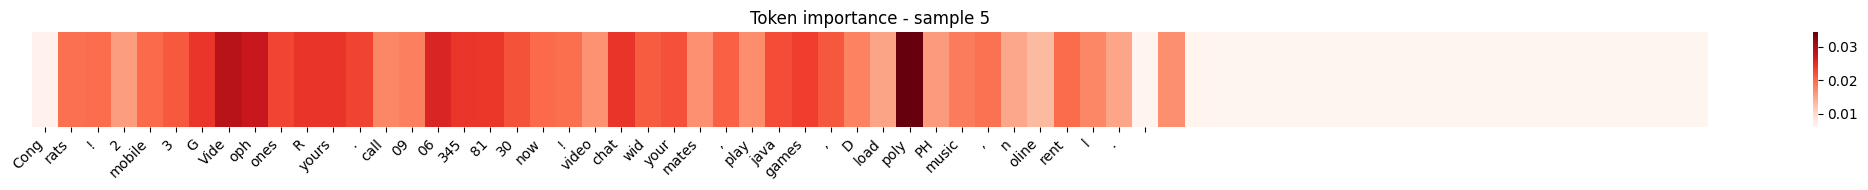

In [ ]:
plot_heatmap(contribution_anom, tokens_anom, idx=5)

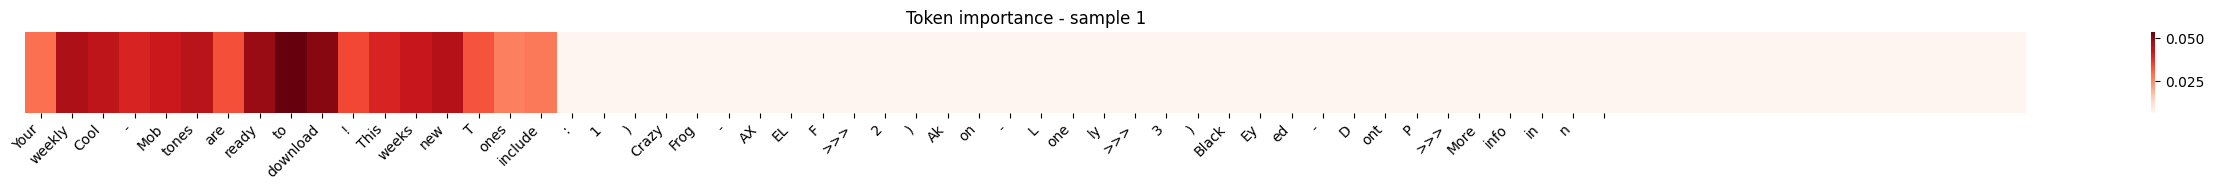

In [ ]:
plot_heatmap(contribution_inli, tokens_inli, idx=1)

In [ ]:
def plot_attention_maps(all_attentions, tokens_text, sample_idx=0):
    """
    all_attentions : (n_blocks, B, T, T)
    tokens_text    : liste de strings
    sample_idx     : quel sample visualiser
    """
    n_blocks = all_attentions.shape[0]
    T        = len(tokens_text)

    fig, axes = plt.subplots(1, n_blocks, figsize=(8 * n_blocks, 5))
    if n_blocks == 1:
        axes = [axes]

    for block_idx, ax in enumerate(axes):

        # Attention map du bloc block_idx pour le sample sample_idx
        attn = all_attentions[block_idx, sample_idx, :T, :T].cpu().numpy()

        sns.heatmap(
            attn,
            xticklabels=tokens_text,
            yticklabels=tokens_text,
            cmap='Blues',
            ax=ax,
            vmin=0, vmax=1,
            annot=True if T <= 10 else False,
            fmt='.2f'
        )
        ax.set_title(f'Block {block_idx} — Attention Map')
        ax.set_xlabel('Key tokens')
        ax.set_ylabel('Query tokens')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('attention_maps.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
x_tokens = X_test[y_test==0][:10].to(device)
all_attentions = fm_transformer.get_attention_maps(x_tokens, t_val=0.5)

tokens_inli = get_tokens(tokenizer, test_data_inli)[:10]
plot_attention_maps(all_attentions, tokens_inli[3], sample_idx=3)

NameError: name 'test_data_inli' is not defined

## Data

In [ ]:
dataset_name = '20newsgroups'
inlier_topic = 'computer'
type_tac = None
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

model.eval()

@torch.no_grad()
def encode_tokens(texts, device, batch_size=16, max_length=128):
    all_embeddings = []
    all_tokens = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)
        last_hidden_state = outputs.last_hidden_state  # (B, T, D)

        # 🔥 normalisation token-wise (important pour distances locales)
        emb = torch.nn.functional.normalize(last_hidden_state, p=2, dim=2)

        all_embeddings.append(emb.cpu())

        # récupérer les tokens
        tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in inputs["input_ids"]]
        all_tokens.extend(tokens)

    return torch.cat(all_embeddings, dim=0).to(device), all_tokens

X_tokens_train, tokens_train = encode_tokens(data_train['text'], device)
X_tokens_test, tokens_test = encode_tokens(data_test['text'], device)
print(X_tokens_train.shape, X_tokens_test.shape)

## EBMs

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
nb_random_samples = 1000

config = {
        'latent_dim': 768,
        'hidden_dim': 256,
        'depth': 4,
        'n_heads': 4,
        'mlp_ratio': 4.0,
        'n_patches': 1,
        'freq_embed_size': 128,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'lambda_svdd': 1e-3,
        'lambda_push': 1e-3,
        'lambda_margin': 1e-4,
        'epochs': 1000,
        'lr_epochs': 300,
        'warmup_epochs': -1,
        'grad_clip': 0.5,
        'flow_type': 'linear',
        'sigma': 0.1,
        'batch_size' : 256,
        'lambda_reg_angle': None,
        'lambda_reg_kl': None,
        'n_step_euler_integrate' : 1,
        'coef_var': 1,
        'rate_neg_batch':1.0,
        'sig_levels_neg' : [0.5, 0.7],
        'target' : 'gaussian-neigh',
        'source' : X_inlier.to(device)
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert',
    'source' : config['source'] if not noise_is_target else 'SBert'
}

In [ ]:
for _ in range(1):

    flowmodel = FlowDiT(
                latent_dim=config['latent_dim'],
                hidden_dim=config['hidden_dim'],
                depth=config['depth'],
                n_heads=config['n_heads']
        ).to(device)

    fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)
    total_loss_liste, loss_fm_liste, loss_svdd_liste, loss_push_liste, margin_value_liste, r_in_value_liste = fm_transformer.train(True)

    print(fm_transformer.test(X_test, y_test, X_inlier, 'norm-centroid'))
    # print(fm_transformer.test(X_tokens_test, y_test, X_tokens_train, 'norm-centroid'))
    # print(fm_transformer.test(X_tokens_test[:1500], y_test[:1500], X_tokens_train, 'norm-centroid'))

    epochs = np.arange(len(total_loss_liste))

    r_in = np.array(r_in_value_liste)
    margin = np.array(margin_value_liste)
    r_out = r_in + margin

    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    axs[0].plot(epochs, total_loss_liste, label="total_loss")
    axs[0].set_title("Total Loss")
    axs[0].legend()

    axs[1].plot(epochs, loss_fm_liste, label="loss_fm")
    axs[1].set_title("Loss FM")
    axs[1].legend()

    axs[2].plot(epochs, loss_svdd_liste, label="loss_svdd")
    axs[2].set_title("Loss SVDD")
    axs[2].legend()

    axs[3].plot(epochs, loss_push_liste, label="loss_push")
    axs[3].set_title("Losses Push")
    axs[3].legend()

    axs[4].plot(epochs, r_in, label="r_in")
    # axs[3].plot(epochs, margin, label="margin")
    axs[4].plot(epochs, r_out, label="r_out")
    axs[4].set_title("Radii Evolution")
    axs[4].legend()

    plt.tight_layout()
    plt.show()

    # --------------------------
    # Train Inliers
    # --------------------------
    dist_train_inlier = torch.sum(
        (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_train_inlier_r_in = ((dist_train_inlier < fm_transformer.r_in).float().mean() * 100).item()
    rate_train_inlier_r_in_r_out = (((dist_train_inlier >= fm_transformer.r_in) & (dist_train_inlier < fm_transformer.r_out)).float().mean() * 100).item()
    rate_train_inlier_r_out = ((dist_train_inlier >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Train-inliers dans r_in : {rate_train_inlier_r_in:.1f}%")
    print(f"% Train-inliers entre r_in et r_out : {rate_train_inlier_r_in_r_out:.1f}%")
    print(f"% Train-inliers dans r_out : {rate_train_inlier_r_out:.1f}%")
    print("--------------------------")

    nb_samples_neg = 130

    sigma_levels = [
        # 0.3 * torch.sqrt(fm_transformer.var),
        # 0.5 * torch.sqrt(fm_transformer.var)
        config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
        config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
    ]
    x_0_negative = []

    for i,sig in enumerate(sigma_levels):

        eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
        x_0_negative.extend(fm_transformer.centroid + eps)

    x_0_negative = torch.stack(x_0_negative).to(device)

    # --------------------------
    # Train Pseudo-Anomalies
    # --------------------------
    dist_train_pseudo = torch.sum(
        (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_train_pseudo_r_in = ((dist_train_pseudo < fm_transformer.r_in).float().mean() * 100).item()
    rate_train_pseudo_r_in_r_out = (((dist_train_pseudo >= fm_transformer.r_in) & (dist_train_pseudo < fm_transformer.r_out)).float().mean() * 100).item()
    rate_train_pseudo_r_out = ((dist_train_pseudo >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Train-PseudoAnom dans r_in : {rate_train_pseudo_r_in:.1f}%")
    print(f"% Train-PseudoAnom entre r_in et r_out : {rate_train_pseudo_r_in_r_out:.1f}%")
    print(f"% Train-PseudoAnom dans r_out : {rate_train_pseudo_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Test Inliers
    # --------------------------
    X_test_inlier = X_test[y_test == 0]

    dist_test_inlier = torch.sum(
        (fm_transformer.forward_flow(X_test_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_test_inlier_r_in = ((dist_test_inlier < fm_transformer.r_in).float().mean() * 100).item()
    rate_test_inlier_r_in_r_out = (((dist_test_inlier >= fm_transformer.r_in) & (dist_test_inlier < fm_transformer.r_out)).float().mean() * 100).item()
    rate_test_inlier_r_out = ((dist_test_inlier >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Test-inliers dans r_in : {rate_test_inlier_r_in:.1f}%")
    print(f"% Test-inliers entre r_in et r_out : {rate_test_inlier_r_in_r_out:.1f}%")
    print(f"% Test-inliers dans r_out : {rate_test_inlier_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Test Anomalies
    # --------------------------
    X_test_anom = X_test[y_test == 1]

    dist_test_anom = torch.sum(
        (fm_transformer.forward_flow(X_test_anom, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_test_anom_r_in = ((dist_test_anom < fm_transformer.r_in).float().mean() * 100).item()
    rate_test_anom_r_in_r_out = (((dist_test_anom >= fm_transformer.r_in) & (dist_test_anom < fm_transformer.r_out)).float().mean() * 100).item()
    rate_test_anom_r_out = ((dist_test_anom >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Test-anomalies dans r_in : {rate_test_anom_r_in:.1f}%")
    print(f"% Test-anomalies entre r_in et r_out : {rate_test_anom_r_in_r_out:.1f}%")
    print(f"% Test-anomalies dans r_out : {rate_test_anom_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Statistiques globales
    # --------------------------
    print(f"dist moyenne Train inliers     : {dist_train_inlier.mean():.4f}")
    print(f"dist moyenne Train pseudoAno   : {dist_train_pseudo.mean():.4f}")
    print(f"dist moyenne Test inliers      : {dist_test_inlier.mean():.4f}")
    print(f"dist moyenne Test anomalies    : {dist_test_anom.mean():.4f}")
    print(f"Gap Test : inliers/anomalies   : {dist_test_anom.mean() - dist_test_inlier.mean():.4f}")
    d_cohen = (dist_test_anom.mean() - dist_test_inlier.mean()) / (
        torch.sqrt((dist_test_inlier.var() + dist_test_anom.var()) / 2)
    )
    print(f"Cohen's d : {d_cohen:.4f}")
    print(f"r_in                            : {fm_transformer.r_in.item():.4f}")
    print(f"r_out                           : {fm_transformer.r_out.item():.4f}")
    print()
    distances, delta_dist, global_direction = trajectory_direction(fm_transformer, X_test, N_steps=50, device=device)
    print(f" Test Nb INLIER Examples diverge from centroid {(global_direction[y_test == 0][global_direction[y_test == 0] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb INLIER Examples converge to centroid {(global_direction[y_test == 0][global_direction[y_test == 0] < 0].shape[0] / X_test.shape[0])*100}%")

    print(f" Test Nb ANOMALIES Examples diverge from centroid {(global_direction[y_test == 1][global_direction[y_test == 1] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb ANOMALIES Examples converge to centroid {(global_direction[y_test == 1][global_direction[y_test == 1] < 0].shape[0] / X_test.shape[0])*100}%")
    print()
    distances, delta_dist, global_direction = trajectory_direction(fm_transformer, X_inlier, N_steps=50, device=device)
    print(f" Train Nb Examples diverge from centroid {(global_direction[global_direction > 0].shape[0] / X_inlier.shape[0])*100}%")
    print(f" Train Nb Examples converge to centroid {(global_direction[global_direction < 0].shape[0] / X_inlier.shape[0])*100}%")

In [ ]:
def visualize_trajectories(model, X_inlier, X_anomaly, n_samples=50, N_steps=20, device=device):
    model.eval()

    with torch.no_grad():
        # Collecte les trajectoires complètes
        def get_trajectory(x):
            trajectory = [x.clone()]
            dt = 1.0 / N_steps
            x_t = x.clone()
            for i in range(N_steps):
                t_val = i * dt
                t = torch.full((x_t.shape[0],), t_val, device=device)
                v = model(x_t, t)
                x_t = x_t + dt * v
                trajectory.append(x_t.clone())
            return torch.stack(trajectory)  # (N_steps+1, B, D)

        traj_in  = get_trajectory(X_inlier[:n_samples])   # (21, 50, 768)
        traj_out = get_trajectory(X_anomaly)  # (21, 50, 768)

    # PCA sur tous les points pour projection cohérente
    all_points = torch.cat([
        traj_in.reshape(-1, 768),
        traj_out.reshape(-1, 768)
    ], dim=0).cpu().numpy()

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(all_points)

    # Projette les trajectoires
    traj_in_2d  = pca.transform(traj_in.reshape(-1, 768).cpu().numpy())
    traj_out_2d = pca.transform(traj_out.reshape(-1, 768).cpu().numpy())

    traj_in_2d  = traj_in_2d.reshape(N_steps+1, n_samples, 2)
    traj_out_2d = traj_out_2d.reshape(N_steps+1, X_anomaly.shape[0], 2)

    return traj_in, traj_out, traj_in_2d, traj_out_2d, pca

In [ ]:
traj_inliers = {}
traj_anomalies = {}
traj_inliers_all_dim = {}
traj_anomalies_all_dim = {}
pca_s = {}

n_samples = 200


traj_inliers_all_dim, traj_anomalies_all_dim, traj_inliers, traj_anomalies, pca_s = visualize_trajectories(fm_transformer.model, X_test[y_test==0], X_test[y_test==1], n_samples=n_samples, N_steps=20, device=device)

# nb_samples_neg = int(n_samples / 2)

# sigma_levels = [
#     # 0.3 * torch.sqrt(fm_transformer.var),
#     # 0.5 * torch.sqrt(fm_transformer.var)

#     config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
#     config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
# ]
# x_0_negative = []

# for i,sig in enumerate(sigma_levels):

#     eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
#     x_0_negative.extend(fm_transformer.centroid + eps)

# x_0_negative = torch.stack(x_0_negative).to(device)


# p = 0.10
# sigma = 0.85
# mask = torch.rand_like(X_inlier) < p  # p = proportion de dims perturbées
# noise = torch.randn_like(X_inlier) * sigma
# x_0_negative = X_inlier + mask * noise

# direction = torch.randn_like(X_inlier)
# direction = direction / direction.norm(dim=1, keepdim=True)
# alpha = 1.1
# x_0_negative = X_inlier + alpha * direction

# traj_inliers_all_dim, traj_anomalies_all_dim, traj_inliers, traj_anomalies, pca_s = visualize_trajectories(fm_transformer.model, X_inlier, x_0_negative, n_samples=n_samples, N_steps=20, device=device)

In [ ]:
title = ''

n_samples_ano = 96

traj_in_2d = traj_inliers
traj_out_2d = traj_anomalies

fig, ax = plt.subplots(figsize=(6, 6))

# Inliers
for i in range(n_samples):
    ax.plot(
        traj_in_2d[:, i, 0], traj_in_2d[:, i, 1],
        color='blue', alpha=0.2, linewidth=0.8
    )
    ax.scatter(
        traj_in_2d[-1, i, 0], traj_in_2d[-1, i, 1],
        color='navy', s=40, marker='.',
        label='Inlier' if i == 0 else None
    )

# Anomalies
for i in range(n_samples_ano):
    ax.scatter(
        traj_out_2d[-1, i, 0], traj_out_2d[-1, i, 1],
        color='darkred', s=40, marker='.',
        label='Anomaly' if i == 0 else None
    )
    ax.plot(
        traj_out_2d[:, i, 0], traj_out_2d[:, i, 1],
        color='red', alpha=0.2, linewidth=0.8
    )

# Centroid
centroid_2d = pca_s.transform(
    fm_transformer.centroid.cpu().numpy().reshape(1, -1)
)

ax.scatter(
    centroid_2d[0, 0], centroid_2d[0, 1],
    color='green', s=200, marker='+', linewidth=1,
    label='Centroid μ'
)

ax.set_title(title, fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# 1. Génération anomalies
# =========================
# direction = torch.randn_like(X_inlier)
# direction = direction / direction.norm(dim=1, keepdim=True)

# alpha = 3.1
# X_anomaly = X_inlier + alpha * direction

# nb_samples_neg = X_inlier.shape[0]

# sigma_levels = [
#     2.8 * torch.sqrt(fm_transformer.var),
#     2.9 * torch.sqrt(fm_transformer.var)

#     # config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
#     # config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
# ]
# x_0_negative = []

# for i,sig in enumerate(sigma_levels):

#     eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
#     x_0_negative.extend(fm_transformer.centroid + eps)

# X_anomaly = torch.stack(x_0_negative).to(device)

p = 0.10
sigma = 0.75
mask = torch.rand_like(X_inlier) < p  # p = proportion de dims perturbées
noise = torch.randn_like(X_inlier) * sigma
X_anomaly = X_inlier + mask * noise

# =========================
# 2. PCA fit sur inliers
# =========================
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_inlier_np = X_inlier.cpu().numpy()
X_anomaly_np = X_anomaly.cpu().numpy()

# Fit uniquement sur les inliers (important)
X_inlier_2d = pca_2d.fit_transform(X_inlier_np)
X_anomaly_2d = pca_2d.transform(X_anomaly_np)

X_inlier_3d = pca_3d.fit_transform(X_inlier_np)
X_anomaly_3d = pca_3d.transform(X_anomaly_np)

# =========================
# 3. Plot
# =========================
fig = plt.figure(figsize=(12, 5))
n_samples = 100

# ---- 2D ----
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_inlier_2d[:n_samples, 0], X_inlier_2d[:n_samples, 1], alpha=0.5, label="Inliers")
ax1.scatter(X_anomaly_2d[:n_samples, 0], X_anomaly_2d[:n_samples, 1], alpha=0.5, label="Anomalies")
ax1.set_title("PCA 2D")
ax1.legend()

# ---- 3D ----
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_inlier_3d[:n_samples, 0], X_inlier_3d[:n_samples, 1], X_inlier_3d[:n_samples, 2],
            alpha=0.5, label="Inliers")
ax2.scatter(X_anomaly_3d[:n_samples, 0], X_anomaly_3d[:n_samples, 1], X_anomaly_3d[:n_samples, 2],
            alpha=0.5, label="Anomalies")
ax2.set_title("PCA 3D")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
partitions = ['svdd1e-1','svdd1e-2', 'svdd1e-3', 'svdd1e-4']

dict_fmt_models = {}

for part in partitions:

    name = f"{dataset_name}_{inlier_topic}_{n_run}_{part}"
    model_saving_path = f"/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}"

    checkpoint = torch.load(model_saving_path, map_location=device)
    config = checkpoint["config"]

    flowmodel = FlowDiT(
        latent_dim=config['latent_dim'],
        hidden_dim=config['hidden_dim'],
        depth=config['depth'],
        n_heads=config['n_heads']
    ).to(device)

    flowmodel.load_state_dict(checkpoint["model"])
    flowmodel.eval()

    dict_fmt_models[part] = FlowMatchingTransformers(
        flowmodel,
        config['source'],
        config['target'],
        config,
        noise_is_target=True,
        rectified=None
    )

In [ ]:
for part in partitions:
    print(dict_fmt_models[part].test(X_test, y_test, X_inlier, 'norm-centroid'))
    distances, delta_dist, global_direction = trajectory_direction(dict_fmt_models[part], X_test, N_steps=50, device=device)
    print(f" Test Nb INLIER Examples diverge from centroid {(global_direction[y_test == 0][global_direction[y_test == 0] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb INLIER Examples converge to centroid {(global_direction[y_test == 0][global_direction[y_test == 0] < 0].shape[0] / X_test.shape[0])*100}%")

    print(f" Test Nb ANOMALIES Examples diverge from centroid {(global_direction[y_test == 1][global_direction[y_test == 1] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb ANOMALIES Examples converge to centroid {(global_direction[y_test == 1][global_direction[y_test == 1] < 0].shape[0] / X_test.shape[0])*100}%")
    print()
    print()

In [ ]:
traj_inliers = {}
traj_anomalies = {}
traj_inliers_all_dim = {}
traj_anomalies_all_dim = {}
pca_s = {}

n_samples = 200

for part in partitions:

    # traj_inliers_all_dim[part], traj_anomalies_all_dim[part], traj_inliers[part], traj_anomalies[part], pca_s[part] = visualize_trajectories(dict_fmt_models[part].model, X_test[y_test == 0], X_test[y_test == 1], n_samples=n_samples, N_steps=20, device=device)

    nb_samples_neg = int(n_samples / 2)

    sigma_levels = [
        # 0.3 * torch.sqrt(fm_transformer.var),
        # 0.5 * torch.sqrt(fm_transformer.var)

        config['sig_levels_neg'][0] * torch.sqrt(dict_fmt_models[part].var),
        config['sig_levels_neg'][1] * torch.sqrt(dict_fmt_models[part].var)
    ]
    x_0_negative = []

    for i,sig in enumerate(sigma_levels):

        eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
        x_0_negative.extend(dict_fmt_models[part].centroid + eps)

    x_0_negative = torch.stack(x_0_negative).to(device)
    traj_inliers_all_dim[part], traj_anomalies_all_dim[part], traj_inliers[part], traj_anomalies[part], pca_s[part] = visualize_trajectories(dict_fmt_models[part].model, X_inlier, x_0_negative, n_samples=n_samples, N_steps=20, device=device)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=False, sharey=False)
n_samples_ano = X_test[y_test == 1].shape[0]
# n_samples_ano = x_0_negative.shape[0]
# partitions = ['margin1e-1','margin1e-2', 'margin1e-3', 'margin1e-4']
mapp = {'Push 1e-1':partitions[0],
        'Push 1e-2':partitions[1],
        'Push 1e-3':partitions[2],
        'Push 1e-4':partitions[3]}

for ax, (traj_in_2d, traj_out_2d), title in zip(
    axes,
    [(traj_inliers[partitions[0]], traj_anomalies[partitions[0]]), (traj_inliers[partitions[1]], traj_anomalies[partitions[1]]),
      (traj_inliers[partitions[2]], traj_anomalies[partitions[2]]), (traj_inliers[partitions[3]], traj_anomalies[partitions[3]]) ],
    mapp.keys()

):
    # Trajectoires inliers
    for i in range(n_samples):
        ax.plot(
            traj_in_2d[:, i, 0], traj_in_2d[:, i, 1],
            color='blue', alpha=0.2, linewidth=0.8,
            # label='Trajectory' if i == 0 else None
        )
        # Point de départ
        # ax.scatter(traj_in_2d[0, i, 0],  traj_in_2d[0, i, 1],
        #           color='blue', s=20, zorder=5,marker='*',
        #           label='Start' if i == 0 else None)
        # Point d'arrivée
        ax.scatter(traj_in_2d[-1, i, 0], traj_in_2d[-1, i, 1],
                  color='navy', s=40, marker='.', zorder=5,
                  label='Inlier' if i == 0 else None)

    # Trajectoires anomalies
    for i in range(n_samples_ano):
        ax.plot(
            traj_out_2d[:, i, 0], traj_out_2d[:, i, 1],
            color='red', alpha=0.2, linewidth=0.8,
            #  label='Trajectory' if i == 0 else None
        )
        # ax.scatter(traj_out_2d[0, i, 0],  traj_out_2d[0, i, 1],
        #           color='red', s=20, zorder=5,marker='*',
        #           label='Start' if i == 0 else None)
        ax.scatter(traj_out_2d[-1, i, 0], traj_out_2d[-1, i, 1],
                  color='darkred', s=40, marker='.', zorder=5,
                  label='Anomaly' if i == 0 else None)

    # Centroid
    centroid_2d = pca_s[mapp[title]].transform(dict_fmt_models[mapp[title]].centroid.cpu().numpy().reshape(1, -1))
    ax.scatter(centroid_2d[0, 0], centroid_2d[0, 1],
              color='green', s=200, marker='+', linewidth=1,
              zorder=10, label='Centroid μ')

    # from matplotlib.patches import Circle

    # circle_r2 = Circle(
    # (centroid_2d[0, 0], centroid_2d[0, 1]),
    # radius=radius_s[title][0],
    # fill=False,
    # linestyle='--',
    # linewidth=1.5,
    # color='green'
    # )

    # circle_r4 = Circle(
    #     (centroid_2d[0, 0], centroid_2d[0, 1]),
    #     radius=radius_s[title][1],
    #     fill=False,
    #     linestyle='-',
    #     linewidth=1.5,
    #     color='red'
    # )

    # ax.add_patch(circle_r2)
    # ax.add_patch(circle_r4)

    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
distances, delta_dist, global_direction = trajectory_direction(dict_fmt_models['with_all'], X_test, N_steps=20, device=device)


In [ ]:
N_steps = 20
algo = 'onlyfm'

dist_in,  delta_in,  dir_in  = trajectory_direction(dict_fmt_models[algo], X_test[y_test == 0], N_steps=N_steps, device=device)
dist_out, delta_out, dir_out = trajectory_direction(dict_fmt_models[algo], X_test[y_test == 1], N_steps=N_steps, device=device)

t_axis = np.linspace(0, 1, N_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1 : distance au centroid au fil du temps ---
ax = axes[0]

# Moyenne + std sur tous les samples
mean_in  = dist_in.mean(dim=1).numpy()   # (N_steps+1,)
std_in   = dist_in.std(dim=1).numpy()
mean_out = dist_out.mean(dim=1).numpy()
std_out  = dist_out.std(dim=1).numpy()

ax.plot(t_axis, mean_in,  color='blue', linewidth=2, label='Inliers')
ax.fill_between(t_axis,
                mean_in - std_in,
                mean_in + std_in,
                alpha=0.2, color='blue')

ax.plot(t_axis, mean_out, color='red',  linewidth=2, label='Anomalies')
ax.fill_between(t_axis,
                mean_out - std_out,
                mean_out + std_out,
                alpha=0.2, color='red')

ax.axhline(0, color='green', linestyle='--', linewidth=1, label='Centroid μ')
ax.set_xlabel('t (flow time)', fontsize=12)
ax.set_ylabel('Distance to centroid μ', fontsize=12)
ax.set_title('Distance evolution along trajectory', fontsize=13)
ax.legend()

# --- Plot 2 : delta_dist (sens du mouvement) ---
ax = axes[1]

mean_delta_in  = delta_in.mean(dim=1).numpy()   # (N_steps,)
mean_delta_out = delta_out.mean(dim=1).numpy()
t_delta = np.linspace(0, 1, N_steps)

ax.plot(t_delta, mean_delta_in,  color='blue', linewidth=2, label='Inliers')
ax.plot(t_delta, mean_delta_out, color='red',  linewidth=2, label='Anomalies')
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Zone de convergence vs divergence
ax.fill_between(t_delta, mean_delta_in, 0,
                where=(mean_delta_in < 0),
                alpha=0.3, color='blue', label='Converging')
ax.fill_between(t_delta, mean_delta_out, 0,
                where=(mean_delta_out > 0),
                alpha=0.3, color='red', label='Diverging')

ax.set_xlabel('t (flow time)', fontsize=12)
ax.set_ylabel('Δ distance (convergent < 0, divergent > 0)', fontsize=12)
ax.set_title('Direction of transport', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('trajectory_directions.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
dir_out

In [ ]:
print(fm_transformer.r_in.item(), fm_transformer.margin.item(), fm_transformer.r_out.item())

In [ ]:
nb_samples_neg = 130

sigma_levels = [
    # 0.3 * torch.sqrt(fm_transformer.var),
    # 0.5 * torch.sqrt(fm_transformer.var)
    config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
    config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
]
x_0_negative = []

for i,sig in enumerate(sigma_levels):

    eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
    x_0_negative.extend(fm_transformer.centroid + eps)

x_0_negative = torch.stack(x_0_negative).to(device)

In [ ]:
# --------------------------
# Train Inliers
# --------------------------
dist_train_inlier = torch.sum(
    (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_train_inlier_r_in = ((dist_train_inlier < fm_transformer.r_in).float().mean() * 100).item()
rate_train_inlier_r_in_r_out = (((dist_train_inlier >= fm_transformer.r_in) & (dist_train_inlier < fm_transformer.r_out)).float().mean() * 100).item()
rate_train_inlier_r_out = ((dist_train_inlier >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Train-inliers dans r_in : {rate_train_inlier_r_in:.1f}%")
print(f"% Train-inliers entre r_in et r_out : {rate_train_inlier_r_in_r_out:.1f}%")
print(f"% Train-inliers dans r_out : {rate_train_inlier_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Train Pseudo-Anomalies
# --------------------------
dist_train_pseudo = torch.sum(
    (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_train_pseudo_r_in = ((dist_train_pseudo < fm_transformer.r_in).float().mean() * 100).item()
rate_train_pseudo_r_in_r_out = (((dist_train_pseudo >= fm_transformer.r_in) & (dist_train_pseudo < fm_transformer.r_out)).float().mean() * 100).item()
rate_train_pseudo_r_out = ((dist_train_pseudo >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Train-PseudoAnom dans r_in : {rate_train_pseudo_r_in:.1f}%")
print(f"% Train-PseudoAnom entre r_in et r_out : {rate_train_pseudo_r_in_r_out:.1f}%")
print(f"% Train-PseudoAnom dans r_out : {rate_train_pseudo_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Test Inliers
# --------------------------
X_test_inlier = X_test[y_test == 0]

dist_test_inlier = torch.sum(
    (fm_transformer.forward_flow(X_test_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_test_inlier_r_in = ((dist_test_inlier < fm_transformer.r_in).float().mean() * 100).item()
rate_test_inlier_r_in_r_out = (((dist_test_inlier >= fm_transformer.r_in) & (dist_test_inlier < fm_transformer.r_out)).float().mean() * 100).item()
rate_test_inlier_r_out = ((dist_test_inlier >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Test-inliers dans r_in : {rate_test_inlier_r_in:.1f}%")
print(f"% Test-inliers entre r_in et r_out : {rate_test_inlier_r_in_r_out:.1f}%")
print(f"% Test-inliers dans r_out : {rate_test_inlier_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Test Anomalies
# --------------------------
X_test_anom = X_test[y_test == 1]

dist_test_anom = torch.sum(
    (fm_transformer.forward_flow(X_test_anom, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_test_anom_r_in = ((dist_test_anom < fm_transformer.r_in).float().mean() * 100).item()
rate_test_anom_r_in_r_out = (((dist_test_anom >= fm_transformer.r_in) & (dist_test_anom < fm_transformer.r_out)).float().mean() * 100).item()
rate_test_anom_r_out = ((dist_test_anom >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Test-anomalies dans r_in : {rate_test_anom_r_in:.1f}%")
print(f"% Test-anomalies entre r_in et r_out : {rate_test_anom_r_in_r_out:.1f}%")
print(f"% Test-anomalies dans r_out : {rate_test_anom_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Statistiques globales
# --------------------------
print(f"dist moyenne Train inliers     : {dist_train_inlier.mean():.4f}")
print(f"dist moyenne Train pseudoAno   : {dist_train_pseudo.mean():.4f}")
print(f"dist moyenne Test inliers      : {dist_test_inlier.mean():.4f}")
print(f"dist moyenne Test anomalies    : {dist_test_anom.mean():.4f}")
print(f"Gap Test : inliers/anomalies   : {dist_test_anom.mean() - dist_test_inlier.mean():.4f}")
d_cohen = (dist_test_anom.mean() - dist_test_inlier.mean()) / (
    torch.sqrt((dist_test_inlier.var() + dist_test_anom.var()) / 2)
)
print(f"Cohen's d : {d_cohen:.4f}")
print(f"r_in                            : {fm_transformer.r_in.item():.4f}")
print(f"r_out                           : {fm_transformer.r_out.item():.4f}")

In [ ]:
margin = np.array(margin_value_liste)
r_in = np.array(r_in_value_liste)
r_out = r_in + margin

epochs = np.linspace(1, len(r_in)-1, 10, dtype=int)

rmax = r_out.max()

fig, axes = plt.subplots(2, 5, figsize=(18,7))

for ax, e in zip(axes.flatten(), epochs):

    rin = r_in[e]
    rout = r_out[e]

    # surfaces
    area_total = np.pi * rmax**2
    area_in = np.pi * rin**2
    area_margin = np.pi * (rout**2 - rin**2)
    area_out = np.pi * (rmax**2 - rout**2)

    p_in = 100 * area_in / area_total
    p_margin = 100 * area_margin / area_total
    p_out = 100 * area_out / area_total

    # fond = région outliers
    ax.set_facecolor("#DBF7D0")

    # disque inliers
    circle_in = plt.Circle((0,0), rin, color="#195401", alpha=0.8)
    margin_cut = plt.Circle((0,0), rout, color="white")

    ax.add_patch(margin_cut)
    ax.add_patch(circle_in)

    # frontières
    ax.add_patch(plt.Circle((0,0), rin, fill=False, linewidth=2))
    ax.add_patch(plt.Circle((0,0), rout, fill=False, linestyle="--", linewidth=2))

    ax.set_xlim(-1.1*rmax, 1.1*rmax)
    ax.set_ylim(-1.1*rmax, 1.1*rmax)
    ax.set_aspect('equal')

    ax.set_title(f"Epoch {e}")

    # label en haut à droite
    label = (
        f"in: {p_in:.1f}%\n"
        f"margin: {p_margin:.1f}%\n"
        f"out: {p_out:.1f}%"
    )

    ax.text(
        0.97, 0.97,
        label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
labels = ["Train Inliers", "Train PseudoAno", "Test Inliers", "Test Anomalies"]

inside_rin = [rate_train_inlier_r_in, rate_train_pseudo_r_in, rate_test_inlier_r_in, rate_test_anom_r_in]
between = [rate_train_inlier_r_in_r_out, rate_train_pseudo_r_in_r_out, rate_test_inlier_r_in_r_out, rate_test_anom_r_in_r_out]
outside = [rate_train_inlier_r_out, rate_train_pseudo_r_out, rate_test_inlier_r_out, rate_test_anom_r_out]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x, inside_rin, label="inside r_in")
plt.bar(x, between, bottom=inside_rin, label="r_in → r_out")

bottom2 = np.array(inside_rin) + np.array(between)
plt.bar(x, outside, bottom=bottom2, label="> r_out")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Percentage")
plt.title("Distribution of samples across regions")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
labels = ["Train Inliers", "Train PseudoAno", "Test Inliers", "Test Anomalies"]
distances = [
    dist_train_inlier.mean().item(),
    dist_train_pseudo.mean().item(),
    dist_test_inlier.mean().item(),
    dist_test_anom.mean().item()
]

colors = ['skyblue', 'lightblue', 'salmon', 'lightcoral']

x = np.array([0, 1, 3, 4])
width = 0.8

plt.figure(figsize=(8,4))
plt.bar(x, distances, width=width, color=colors)

plt.axhline(fm_transformer.r_in.item(), linestyle="--", label="r_in", color='green')
plt.axhline(fm_transformer.r_out.item(), linestyle="--", label="r_out", color='red')

plt.xticks(x, labels)

plt.ylabel("Mean distance to centroid")
plt.title("Average distance to centroid")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

# TRAIN
ax[0].hist(dist_train_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Train Inliers", density=True)
ax[0].hist(dist_train_pseudo.cpu().numpy(), bins=50, alpha=0.7, label="Pseudo Anomalies", density=True)

ax[0].axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
ax[0].axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

ax[0].set_title("Train distances")
ax[0].set_xlabel("Distance")
ax[0].set_ylabel("Density")
ax[0].legend()

# TEST
ax[1].hist(dist_test_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Test Inliers", density=True)
ax[1].hist(dist_test_anom.cpu().numpy(), bins=50, alpha=0.7, label="Test Anomalies", density=True)

ax[1].axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
ax[1].axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

ax[1].set_title("Test distances")
ax[1].set_xlabel("Distance")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
dist_sq = torch.sum((fm_transformer.forward_flow(X_test,'midpoint',8)[-1] - fm_transformer.centroid)**2, dim=1)
r_sq = fm_transformer.r_in ** 2
sss = dist_sq - r_sq
ev.evaluation(y_test, sss.cpu().detach().numpy())

In [ ]:
nb_samples_neg = 130

sigma_levels = [
    0.3 * torch.sqrt(fm_transformer.var),
    0.5 * torch.sqrt(fm_transformer.var)
]
x_0_negative = []

for i,sig in enumerate(sigma_levels):

    eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
    x_0_negative.extend(fm_transformer.centroid + eps)

x_0_negative = torch.stack(x_0_negative).to(device)


alpha = 1.15

direction = X_inlier - fm_transformer.centroid
x_0_negative = fm_transformer.centroid + alpha * direction


dist_train_inlier = torch.sum(
    (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)
dist_train_pseudo = torch.sum(
    (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

fig, ax = plt.subplots(1,1, figsize=(12,4))

# TRAIN
plt.hist(dist_train_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Train Inliers", density=True)
plt.hist(dist_train_pseudo.cpu().numpy(), bins=50, alpha=0.7, label="Pseudo Anomalies", density=True)

plt.axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
plt.axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

plt.title("Train distances")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
n_steps = 8
x_intermer_test_noise = fm_transformer.forward_flow(X_test,'midpoint',n_steps)
x_intermer_inlier_noise = fm_transformer.forward_flow(X_inlier,'midpoint',n_steps)
# x_intermer_test_noise = dict_fmt_models['onlyfm'].forward_flow(X_test,'midpoint',n_steps)
# x_intermer_inlier_noise = dict_fmt_models['onlyfm'].forward_flow(X_inlier,'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), torch.randn(100, X_inlier.shape[1]).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), X_inlier.to(device) )),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate([X_inlier, X_anom_for_train]).to(device),'midpoint',n_steps)

metrics_history_maha = []
metrics_history_norm = []
metrics_history_norm_train = []

for num_repre_space in range(n_steps):

    ############## MANALANOBIS ####################

    x_1_inliers = x_intermer_inlier_noise[num_repre_space].cpu().numpy()

    mean_inlier = np.mean(x_1_inliers, axis=0)
    cov_inlier = np.cov(x_1_inliers.T)
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    diff = x_intermer_test_noise[num_repre_space].cpu().numpy() - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)

    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    metrics_history_maha.append(ev.evaluation(y_test, scores, verbose=False))


    ################### NORM ########################

    # scores = np.sum(x_intermer_test_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    # scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - dict_fmt_models['onlyfm'].centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    metrics_history_norm.append(ev.evaluation(y_test, scores, verbose=False))

    # # # ss = np.sum(x_intermer_inlier_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    # ss = np.sum((x_intermer_inlier_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_inlier_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    # metrics_history_norm_train.append(ev.evaluation(y_train, ss, verbose=False))

metrics_history_maha = np.array(metrics_history_maha)
metrics_history_norm = np.array(metrics_history_norm)
metrics_history_norm_train = np.array(metrics_history_norm_train)

In [ ]:
X_np = x_intermer_test_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        ax_scatter.text(
            0.05, 0.95,
            f"AUC={metrics_history_norm[i][0]:.3f}\n"
            f"FPR95={metrics_history_norm[i][1]:.3f}\n"
            f"AP={metrics_history_norm[i][2]:.3f}",
            transform=ax_scatter.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
X_np = x_intermer_inlier_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            # c=y_train,
            # cmap="bwr",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        # ax_scatter.text(
        #     0.05, 0.95,
        #     f"AUC={metrics_history_norm_train[i][0]:.3f}\n"
        #     f"FPR95={metrics_history_norm_train[i][1]:.3f}\n"
        #     f"AP={metrics_history_norm_train[i][2]:.3f}",
        #     transform=ax_scatter.transAxes,
        #     fontsize=9,
        #     verticalalignment='top',
        #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        # )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
def collect_temporal_metrics(model, x, time_steps):
    norms = []
    dvdt_vals = []

    for t in time_steps:
        t_batch = torch.ones(x.size(0), 1, device=x.device) * t
        t_batch.requires_grad_(True)

        v = model(x, t_batch)

        norm_v = v.norm(dim=1)
        norms.append(norm_v.detach())

        dvdt = torch.autograd.grad(
            norm_v.sum(),
            t_batch,
            retain_graph=True
        )[0]

        dvdt_vals.append(dvdt.detach())

    norms = torch.stack(norms, dim=1)
    dvdt_vals = torch.stack(dvdt_vals, dim=1)

    return norms, dvdt_vals

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
norms_inlier, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_inlier, time_steps)
norms_test, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_test, time_steps)

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, torch.mean(norms_inlier, dim=0).cpu().numpy(), label='Train', color='tab:blue', linewidth=2)
plt.plot(time_steps, torch.mean(norms_test[y_test == 1], dim=0).cpu().numpy(), label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, torch.mean(norms_test[y_test == 0], dim=0).cpu().numpy(), label='Test_Inliers', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
plt.imshow(norms_test[y_test==1].cpu(), aspect='auto')
# plt.imshow(norms_inlier.cpu(), aspect='auto')
plt.colorbar()
plt.title("Velocity norm per sample over time")
plt.show()

In [ ]:
def grad_norm(model, x, t):
    x = x.requires_grad_(True)
    v = model(x, t)

    grad = torch.autograd.grad(
        v.norm(),
        x,
        retain_graph=False,
        create_graph=False
    )[0]

    return grad.norm(dim=1)

In [ ]:
dt = 1.0 / n_steps
l_norm_train = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_inlier.shape[0])
    l_norm_train.append(torch.mean(grad_norm(fm_transformer.model, X_inlier, t)).item())

l_norm_anom = []
l_norm_inlier = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==1].shape[0])
    l_norm_anom.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==1], t)).item())

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==0].shape[0])
    l_norm_inlier.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==0], t)).item())

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, l_norm_train, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, l_norm_anom, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, l_norm_inlier, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
x_bis = fm_transformer.sample_like(X_test, 'gaussian-neigh')

In [ ]:
x0 = X_test
x_t = x0.clone().to(device)
x_traj_test = [x_t.clone()]
v_fields_test = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_test.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_test.append(x_t.clone())

v_fields_test = torch.stack(v_fields_test)
x_traj_test = torch.stack(x_traj_test)

In [ ]:
t = 0
ss = torch.mean((v_fields_test[t] - (X_test - x_bis) ), dim=1)

In [ ]:
ev.evaluation(y_test, ss.detach().cpu().numpy())

In [ ]:
indices_inlier = np.where(y_test == 0)[0]
indices_anomaly = np.where(y_test == 1)[0]

norm_inlier = []
norm_anomaly = []

for t_ in range(n_steps):
    test_velocities_inlier_norm = torch.norm(v_fields_test[t_, indices_inlier], dim=1)
    test_velocities_anomaly_norm = torch.norm(v_fields_test[t_, indices_anomaly], dim=1)

    norm_inlier.append(torch.mean(test_velocities_inlier_norm).item())
    norm_anomaly.append(torch.mean(test_velocities_anomaly_norm).item())

norm_inlier = np.array(norm_inlier)
norm_anomaly = np.array(norm_anomaly)

In [ ]:
# x0 = torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device)))
x0 = X_inlier.to(device)
x_t = x0.clone().to(device)
x_traj_train = [x_t.clone()]
v_fields_train = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_train.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_train.append(x_t.clone())

v_fields_train = torch.stack(v_fields_train)
x_traj_train = torch.stack(x_traj_train)

In [ ]:
norm_train = []
for t_ in range(n_steps):
    train_velocities_norm = torch.norm(v_fields_train[t_, :], dim=1)
    norm_train.append(torch.mean(train_velocities_norm).item())

norm_train = np.array(norm_train)

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, norm_inlier, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, norm_anomaly, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, norm_train, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
torch.mean(torch.norm((fm_transformer.sample(X_test, 'gaussian-neigh') - X_test), dim=1))

In [ ]:
torch.mean(torch.norm((fm_transformer.sample(X_inlier, 'gaussian-neigh') - X_inlier), dim=1))

In [ ]:
torch.mean(v_fields_test[:, y_test==0, :], dim=1).shape

In [ ]:
torch.mean(v_fields_test[:, y_test==1, :], dim=1).shape

In [ ]:
v_in = torch.mean(v_fields_test[:, y_test==0, :], dim=1)
diff = torch.abs(v_in)
importance_in = torch.mean(diff, dim=0)

v_out = torch.mean(v_fields_test[:, y_test==1, :], dim=1)
diff = torch.abs(v_out)
importance_out = torch.mean(diff, dim=0)

top3_values, top3_indices = torch.topk(importance_in, k=3)
print("INLIER")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)
print()
top3_values, top3_indices = torch.topk(importance_out, k=3)
print("ANOMALIES ")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_out.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_in.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

In [ ]:
alpha_s = [0, 1e-4, 1e-2, 1e-1, 0.5, 1]

X = X_inlier[:3]
N, D = X.shape

all_points = []
liste_vt = []

t = torch.tensor([0.25], device=device).expand(N)

for alpha in alpha_s:

    noise = alpha * torch.randn_like(X).to(device)
    x_inlier_noised = X + noise

    v_t = fm_transformer.model(x_inlier_noised, t)
    mean_norm = torch.mean(torch.norm(v_t, dim=1)).item()
    liste_vt.append(mean_norm)

    all_points.append(x_inlier_noised.detach().cpu().numpy())

all_points = np.vstack(all_points)

pca = PCA(n_components=2)
points_2d = pca.fit_transform(all_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
start = 0
for alpha in alpha_s:
    end = start + N
    axes[0].scatter(
        points_2d[start:end, 0],
        points_2d[start:end, 1],
        label=f'alpha={alpha}',
        alpha=0.6
    )
    start = end

axes[0].set_title("Evolution des embeddings bruités (PCA 2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].plot(alpha_s, liste_vt, marker='o')
axes[1].set_title("Evolution de la norme Velocity Field")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean ||v_t||")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import chi2

def belongs_to_gaussian_isotropic(x, mu, sigma, alpha=0.95):
    """
    x : shape (768,) or (n,768)
    mu : shape (768,)
    sigma : scalar (std)
    alpha : confidence level
    """
    x = np.atleast_2d(x)
    d = mu.shape[0]

    diff = x - mu
    maha_sq = np.sum(diff**2, axis=1) / (sigma**2)

    threshold = chi2.ppf(alpha, df=d)

    return maha_sq <= threshold

x = x_intermer_test_noise[-1][0].cpu().numpy()
belongs_to_gaussian_isotropic(x, fm_transformer.centroid.cpu().numpy(), fm_transformer.var.cpu().numpy(), alpha=0.95)

In [ ]:
np.random.seed(0)
mu = np.array([0.0, 0.0])
sigma = 1.0
dim = 2
n_samples = 200
R = 2.5 * sigma

gaussian_samples = np.random.randn(n_samples, dim) * sigma + mu

complementary_samples = []

while len(complementary_samples) < n_samples:
    proposal = np.random.randn(n_samples, dim) * (3 * sigma) + mu
    distances = np.linalg.norm(proposal - mu, axis=1)
    accepted = proposal[distances > R]
    complementary_samples.extend(accepted)

complementary_samples = np.array(complementary_samples[:n_samples])


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Gaussian ----
axes[0].scatter(
    gaussian_samples[:, 0],
    gaussian_samples[:, 1],
    color="royalblue",
    alpha=0.6,
    label="Gaussian samples"
)

circle1 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[0].add_patch(circle1)

# axes[0].set_title("Gaussian", fontsize=13)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_aspect("equal", "box")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Complementary ----
axes[1].scatter(
    complementary_samples[:, 0],
    complementary_samples[:, 1],
    color="crimson",
    alpha=0.6,
    label="Complementary samples"
)

circle2 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[1].add_patch(circle2)

# axes[1].set_title("Complementary Distribution (Outside R)", fontsize=13)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_aspect("equal", "box")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
metric_names = ["AUC", "FPR95", "AP"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i in range(3):
    axes[i].plot(metrics_history_maha[:, i], label="Mahalanobis", marker='o')
    axes[i].plot(metrics_history_norm[:, i], label="Norm", marker='x')
    axes[i].set_title(metric_names[i])
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)


fig.suptitle(
    f"Evolution des métriques selon l’anomaly score à travers {n_steps} sous-espaces ({naming_dis['source']} → {naming_dis['target']})",
    fontsize=14
)

plt.tight_layout()
plt.show()


In [ ]:
print(f" Mahalanobis : {np.mean(metrics_history_maha, axis=0)}, {np.std(metrics_history_maha, axis=0)}")
print(f" Norm : {np.mean(metrics_history_norm, axis=0)}, {np.std(metrics_history_norm, axis=0)}")

In [ ]:
class EBM(nn.Module):
    def __init__(self, input_dim=2, dim_hid=64):
        super().__init__()
        self.dim_hid = dim_hid
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = EBM(x_intermer_inlier_noise[1].shape[1], 64).to(device)

lr = 1e-3
batch_size = 64
epochs = 5
K = 10            # Langevin steps
eta = 1e-1        # step size Langevin
eps = 0.05        # bruit Langevin
optimizer = optim.Adam(model.parameters(), lr=lr)

def langevin_samples(x_init, model, K=20, eta=0.1, eps=0.01):
    x = x_init.clone().detach()
    x.requires_grad_(True)
    for _ in range(K):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        x.data -= eta * grad + torch.randn_like(x) * np.sqrt(2*eta*eps)
    return x.detach()

# data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
X_inlier_dl = DataLoader(TensorDataset(x_intermer_inlier_noise[1]), batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(epochs):
    for x_batch, in X_inlier_dl:
        noise = torch.randn_like(x_batch)
        x_neg_init = torch.cat([x_batch, noise], dim=0)
        x_neg = langevin_samples(x_neg_init, model, K=K, eta=eta, eps=eps)

        energy_pos = model(x_batch)
        energy_neg = model(x_neg)
        loss = (energy_pos.mean() - energy_neg.mean())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: CD loss = {loss.item():.4f}")

plt.plot(loss_history)
plt.title("CD Loss pendant entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
ev.evaluation(y_test, model(x_intermer_test_noise[1]).cpu().detach().numpy())